# Kernel Methods

In **linear parametric models** for regression and classification, the relationship between an input and the corresponding output is described by a parametric function: 

$\displaystyle y(x, w) = w^\top x$

The learning process consists in using a dataset to determine **suitable values for these parameters**. Once training is complete, the dataset itself is no longer needed. All the information extracted from the data is encoded in the parameter vector. As a consequence, predictions for new inputs are obtained solely through the evaluation of the function, without any direct reference to the original training examples. This viewpoint highlights an important property of parametric models: they act as a form of **information compression**, distilling the entire dataset into a finite set of parameters. 

In many applications, **the underlying structure of the data is nonlinear**. In regression, the input–output relationship may not be well approximated by a linear function. In classification, the classes may not be separable by a linear decision boundary. To illustrate this need, consider a dataset that is not linearly separable:

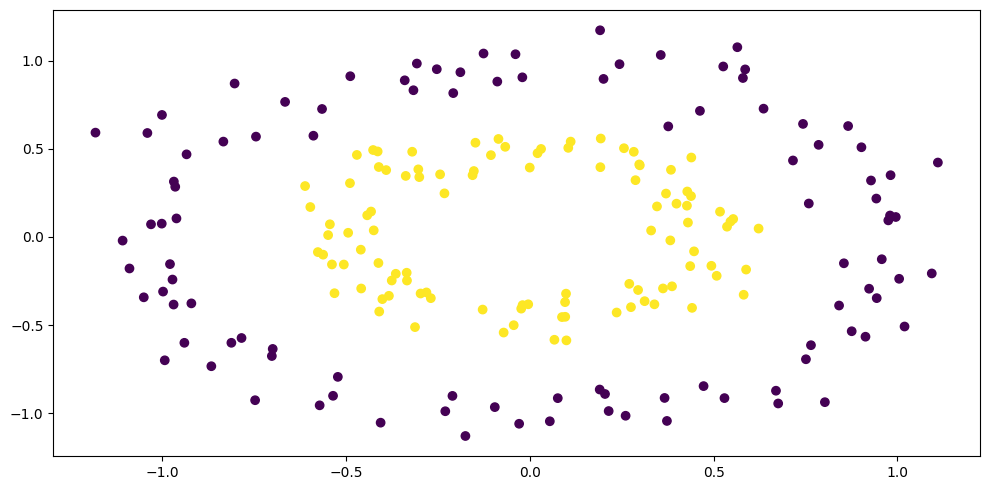

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=200, factor=0.5, noise=0.1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X[:, 0], X[:, 1], c=y)
plt.tight_layout()
plt.show()

If we apply a linear classifier directly to this data, it fails to find a suitable decision boundary.

In [17]:
from sklearn.linear_model import LogisticRegression

model_linear = LogisticRegression()
model_linear.fit(X, y)

LogisticRegression()

A convenient way to visualize the decision function is the following:

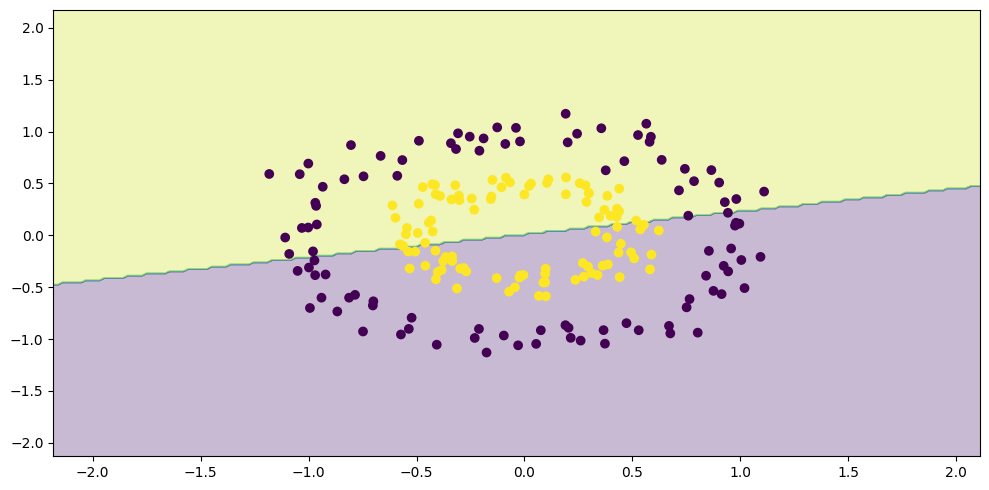

In [18]:
def plot_decision_boundary(model, X, y):
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(model_linear, X, y)

A simple but powerful idea is to **increase the flexibility** of linear models by first transforming the input through a **feature mapping**, a nonlinear transformation that maps the original input space into a higher-dimensional feature space:

$\displaystyle \phi(x)$

and then applying a linear model in this transformed space:

$\displaystyle y(x) = w^\top \phi(x)$

Although **the model remains linear** in the parameters, it can represent **nonlinear relationships** in the original input space. In the example above, we can use a polynomial feature mapping:

$\displaystyle \phi(x)=
\begin{bmatrix}
x_1 \\
x_2 \\
x_1^2 \\
\sqrt{2}\,x_1x_2 \\
x_2^2
\end{bmatrix}$

and then apply a linear classifier in this new feature space.

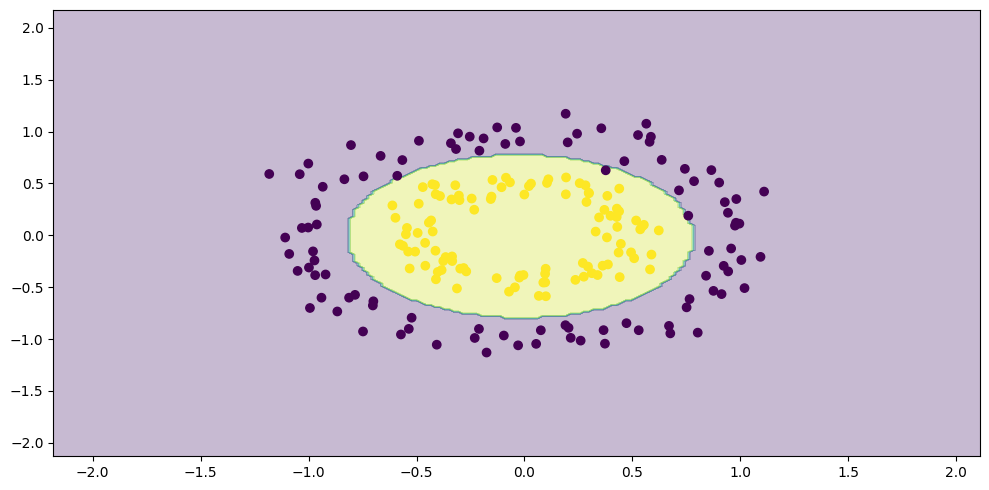

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

model_poly = make_pipeline(
    PolynomialFeatures(degree=2),
    LogisticRegression()
)

model_poly.fit(X, y)

plot_decision_boundary(model_poly, X, y)

This approach allows us to capture more complex patterns in the data, however it can quickly become **computationally expensive**. In many cases, the transformed feature vector has a **much higher dimensionality** than the original input, especially when using polynomial expansions or more complex transformations. To make this problem explicit, we can inspect the transformed features:










In [20]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X[:5])

print("Original inputs:")
print(X[:5])

print("\nMapped features:")
print(X_poly)

print("\nFeature names:")
print(poly.get_feature_names_out(["x1", "x2"]))

Original inputs:
[[ 0.54561279  0.08720636]
 [ 0.92287785 -0.2938114 ]
 [-0.15605944  0.35021908]
 [ 0.74306071  0.64117597]
 [ 0.21427756 -0.98776279]]

Mapped features:
[[ 0.54561279  0.08720636  0.29769332  0.04758091  0.00760495]
 [ 0.92287785 -0.2938114   0.85170352 -0.27115203  0.08632514]
 [-0.15605944  0.35021908  0.02435455 -0.05465499  0.1226534 ]
 [ 0.74306071  0.64117597  0.55213922  0.47643268  0.41110663]
 [ 0.21427756 -0.98776279  0.04591487 -0.2116554   0.97567533]]

Feature names:
['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


As the dimensionality grows, both **the cost of computing the mappings** and **the cost of performing operations in this space** increase significantly. In some important cases, the feature space may even be **infinite-dimensional**, making an explicit computation impractical. This computational challenge motivates the introduction of **kernel methods**, which allow us to work implicitly in high-dimensional feature spaces without ever computing the feature mapping explicitly.

## Dual representations

Many linear models for regression and classification can be **reformulated** in a dual representation, in which the model is expressed in terms of the training data rather than explicit parameters. In this formulation, the kernel function arises naturally as a measure of similarity between inputs, as in instance-based learning.

### Design matrix

Consider a linear regression model of the form:

$\displaystyle y(x) = w^\top \phi(x)$

where 

$\displaystyle \phi(x)$ 

is a (possibly nonlinear) feature mapping. The parameters are determined by minimizing a regularized sum-of-squares error function of the form:

$\displaystyle J(w) = \frac{1}{2} \sum_{n=1}^{N} \left(w^\top \phi(x_n) - t_n \right)^2 + \frac{\lambda}{2} w^\top w$

By setting the gradient of the cost function with respect to the parameters to zero, we obtain that the solution can be expressed as a linear combination of the feature vectors evaluated at the training inputs. The gradient is obtained by differentiating each term. For the data term:

$\displaystyle \nabla_{w} \left( \frac{1}{2} \left(w^\top \phi(x_n) - t_n \right)^2 \right) = \frac{1}{2} 2 \left(w^\top \phi(x_n) - t_n \right) \nabla_{w} \left(w^\top \phi(x_n) - t_n \right) = \left(w^\top \phi(x_n) - t_n \right)\,\phi(x_n)$

Summing over n, we get:

$\displaystyle \nabla_{w} \left( \frac{1}{2} \sum_{n=1}^{N} (w^\top \phi(x_n) - t_n)^2 \right) = \sum_{n=1}^{N} (w^\top \phi(x_n) - t_n)\,\phi(x_n)$

For the regularization term:

$\displaystyle \nabla_{w} \left( \frac{\lambda}{2} w^\top w \right) = \lambda w$

Putting everything together:

$\displaystyle \nabla_{w} J(w) = \sum_{n=1}^{N} (w^\top \phi(x_n) - t_n)\,\phi(x_n) + \lambda w$

Setting thsis equal to zero and solving for w:

$\displaystyle \sum_{n=1}^{N} (w^\top \phi(x_n) - t_n)\,\phi(x_n) + \lambda w = 0$

We can rearrange the expression in order to move the regularization term to the other side:

$\displaystyle \lambda w = - \sum_{n=1}^{N} (w^\top \phi(x_n) - t_n)\,\phi(x_n)$

Then we divede by the regularization parameter in order to express w explicitly:

$\displaystyle w = -\frac{1}{\lambda} \sum_{n=1}^{N} (w^\top \phi(x_n) - t_n)\,\phi(x_n)$

We see that the solution for w takes the form of a linear combination of the feature vectors evaluated at the training inputs, with coefficients that are functions of w:

$\displaystyle w = \sum_{n=1}^{N} a_n \phi(x_n)$

with

$\displaystyle a_n = -\frac{1}{\lambda} \left( w^\top \phi(x_n) - t_n \right)$


We can expresso this using a more compact matrix notation, introducing the **design matrix**, whose rows are the feature vectors evaluated at the training inputs:

$\displaystyle \Phi = \begin{bmatrix} \phi(x_1)^\top \\ \phi(x_2)^\top \\ \vdots \\ \phi(x_N)^\top \end{bmatrix}$

And the vector of the coefficients:

$\displaystyle a = \begin{bmatrix} a_1 = -\frac{1}{\lambda} (w^\top \phi(x_1) - t_1) \\ a_2 = -\frac{1}{\lambda} (w^\top \phi(x_2) - t_2) \\ \vdots \\ a_N = -\frac{1}{\lambda} (w^\top \phi(x_N) - t_N) \end{bmatrix}$

Then we can write:

$\displaystyle w = \Phi^\top a$

### Gram matrix

We can substitute the expression of w into the original regularized least-squares cost:

$\displaystyle J(w)=\frac{1}{2}\sum_{n=1}^N\left(w^\top \phi(x_n)-t_n\right)^2+\frac{\lambda}{2}w^\top w$

It is convenient to rewrite this first in matrix form:

$\displaystyle J(w)=\frac{1}{2}\left\|\Phi w-t\right\|^2+\frac{\lambda}{2}w^\top w$

where 

$\displaystyle t = (t_1,\dots,t_N)^\top$

Now we can make the sustitution for w: 

$\displaystyle J(a) = \frac{1}{2}\left\|\Phi \Phi^\top a - t\right\|^2 + \frac{\lambda}{2} a^\top \Phi \Phi^\top a$

We can definte the **Gram matrix** as:

$\displaystyle K = \Phi \Phi^\top$

Then we can write the cost function as:

$\displaystyle J(a) = \frac{1}{2}\left\|K a - t\right\|^2 + \frac{\lambda}{2} a^\top K a$

Expanding the norm, we get:

$\displaystyle J(a) = \frac{1}{2} a^\top K K a - t^\top K a + \frac{1}{2} t^\top t + \frac{\lambda}{2} a^\top K a$

This is the cost function written entirely in terms of coefficients a. The important point is that the feature vectors appear only through inner products collected in the Gram matrix, which can be computed without ever explicitly evaluating the feature mapping that opens the door to kernel methods.

### Kernel function

The Gram matrix is a matrix of inner products between the feature vectors evaluated at the training inputs:

$\displaystyle K_{nm} = \phi(x_n)^\top \phi(x_m) = k(x_n, x_m)$

We define the **kernel function** as the function that computes the inner product between the feature vectors evaluated at two inputs. So the Gram matrix can be expressed in terms of the kernel function as:

$\displaystyle K = \begin{bmatrix} k(x_1, x_1) & k(x_1, x_2) & \cdots & k(x_1, x_N) \\ k(x_2, x_1) & k(x_2, x_2) & \cdots & k(x_2, x_N) \\ \vdots & \vdots & \ddots & \vdots \\ k(x_N, x_1) & k(x_N, x_2) & \cdots & k(x_N, x_N) \end{bmatrix}$

We can view the matrix K as a measure of similarity between the training inputs, where the similarity is defined in terms of the inner product in the feature space. The kernel function allows us to compute this similarity.

### Solution for the dual problem

We can minimize the cost function with respect to a by setting its gradient to zero:

$\displaystyle \nabla_{a} J(a) = K K a - K t + \lambda K a = 0$

This is a linear system of equations in a, which can be solved to obtain the optimal coefficients. 

$\displaystyle (K K + \lambda K) a = K t$

$\displaystyle a = (K K + \lambda K)^{-1} K t = (K + \lambda I)^{-1} t$

Once the optimal coefficients have been determined, predictions for a new input can be obtained by substituting the dual expression for w into the linear regression model:

$\displaystyle y(x) = w^\top \phi(x) = (\Phi^\top a)^\top \phi(x)$

using the identity 

$\displaystyle (\Phi^\top a)^\top = a^\top \Phi$

we can write:

$\displaystyle y(x) = a^\top \Phi \phi(x)$

The term that multiplies the design matrix by the feature vector is the kernel function evaluated between the training inputs and the new input:

$\displaystyle \Phi \phi(x) = 
\begin{bmatrix}
\phi(x_1)^\top \\
\phi(x_2)^\top \\
\vdots \\
\phi(x_N)^\top
\end{bmatrix} \phi(x) = 
\begin{bmatrix}
\phi(x_1)^\top \phi(x) \\
\phi(x_2)^\top \phi(x) \\
\vdots \\
\phi(x_N)^\top \phi(x)
\end{bmatrix} =
\begin{bmatrix} 
k(x_1, x) \\ 
k(x_2, x) \\ 
\vdots \\ 
k(x_N, x) 
\end{bmatrix}$


Defining the vector of kernel evaluations between the training inputs and the new input as:

$\displaystyle \bold{k}(x) = \begin{bmatrix} k(x_1, x) \\ k(x_2, x) \\ \vdots \\ k(x_N, x) \end{bmatrix}$

We can write the predicion for a new input as the weighted sum of the kernel evaluations:

$\displaystyle y(x) = a^\top \bold{k}(x) = (K + \lambda I)^{-1} t^\top \bold{k}(x) = \bold{k}^\top (K + \lambda I)^{-1} t$

### Kernel trick

A central idea in kernel methods is that, although nonlinear models can be constructed by introducing a feature mapping:

$\phi(x)$

it is often neither necessary nor practical to compute this mapping explicitly. The dual formulation developed above reveals why: the feature vectors never appear in isolation, but only through inner products of the form:

$\displaystyle \phi(x_n)^\top \phi(x_m)$

This suggests that **the feature mapping itself is not required**, it is sufficient to evaluate these inner products. A **kernel function** is any function that computes exactly this quantity:

$\displaystyle k(x_n, x_m) = \phi(x_n)^\top \phi(x_m)$

The equation above is the **definition** of what the kernel represents geometrically (the inner product in the feature space). It is **not** how the kernel is computed in practice. The key insight, known as the **kernel trick**, is that for many useful feature mappings there exists a **direct closed-form expression** for the kernel, that operates entirely in the original input space, without ever constructing the mapping.

Recall the circles dataset considered earlier, where we used a polynomial feature mapping:

$\displaystyle \phi(x)=
\begin{bmatrix}
x_1 \\
x_2 \\
x_1^2 \\
\sqrt{2}\,x_1x_2 \\
x_2^2
\end{bmatrix}$

To understand how a kernel arises, let us compute the inner product between the feature vectors evaluated evaluated at two inputs:

$\displaystyle \phi(x_n)^\top \phi(x_m) = x_{n,1} x_{m,1} + x_{n,2} x_{m,2} + x_{n,1}^2 x_{m,1}^2 + 2 x_{n,1} x_{n,2} x_{m,1} x_{m,2} + x_{n,2}^2 x_{m,2}^2$

The first two terms can be written as

$\displaystyle x_{n,1} x_{m,1} + x_{n,2} x_{m,2} = x_n^\top x_m$

while the remaining terms correspond to

$\displaystyle (x_n^\top x_m)^2 = (x_{n,1} x_{m,1} + x_{n,2} x_{m,2})^2$.

Therefore, we obtain the following expression for the kernel:

$\displaystyle k(x_n, x_m) = (x_n^\top x_m) + (x_n^\top x_m)^2$

This result is remarkable: the kernel can be computed directly from the original inputs, without ever explicitly evaluating the feature mapping. The precise form of the kernel depends on the choice of feature mapping.

We now implement the kernel approach from scratch on the circles dataset. First we define the kernel function corresponding to the polynomial feature mapping:

In [21]:
def kernel(xn, xm):
    dot = xn @ xm
    return dot + dot**2

Next, we construct the Gram matrix for the training set:

In [23]:
N = len(X)
K = np.zeros((N, N))

for n in range(N):
    for m in range(N):
        K[n, m] = kernel(X[n], X[m])

print("Shape of Gram matrix:", K.shape)
print(K[:5, :5])

Shape of Gram matrix: (200, 200)
[[ 0.3985053   0.70631136 -0.0516248   0.67417086  0.03172038]
 [ 0.70631136  1.81792643 -0.18595161  0.74474584  0.72608073]
 [-0.0516248  -0.18595161  0.16861929  0.1203823  -0.23544923]
 [ 0.67417086  0.74474584  0.1203823   1.89108842 -0.24932963]
 [ 0.03172038  0.72608073 -0.23544923 -0.24932963  2.06523675]]


This matrix plays the role of the new feature representation. The n-th row contains the similarities between x_n and all training points. We can now fit logistic regression on this transformed dataset:

In [24]:
clf = LogisticRegression()
clf.fit(K, y)

LogisticRegression()

To classify a new point x, we must represent it in the same way, namely through its similarities to the training set:

In [25]:
def kernel_features(X_train, x, kernel):
    return np.array([kernel(xn, x) for xn in X_train])

x_new = np.array([0.2, 0.1])
k_new = kernel_features(X, x_new, kernel).reshape(1, -1)

prediction = clf.predict(k_new)
print("Predicted class:", prediction[0])

Predicted class: 1


This example illustrates the kernel trick in its most transparent form. We begin with an explicit quadratic feature mapping, which makes the nonlinear structure of the data accessible to a linear classifier. We then observe that the algorithm depends on this mapping only through inner products between transformed inputs. These inner products can be computed directly by a polynomial kernel, without ever constructing the feature vectors themselves. In this way, the kernel method achieves the same effect as the explicit feature mapping, but in a form that generalizes naturally to much richer feature spaces.